# Plot scan

In [1]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../')
from auxPlots import readContours,label_line
import seaborn as sns
pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

#### Get contours from different sources

In [2]:

# Direct Searches
directDict_qq = readContours('./SModelS_contours_Zp_qqbar.csv')
print('Direct Searches qq=',directDict_qq.keys())

# Direct Searches
directDict_tt = readContours('./SModelS_contours_Zp_ttbar.csv')
print('Direct Searches tt=',directDict_tt.keys())


# # Direct searches (SModelS  + MonoJet)
# directDict = {}
# cVals = set(smodelsDict.keys()).intersection(set(monoJetDict.keys()))
# for c in cVals:
#     smodelsCurve = np.array([list(x) for x in smodelsDict[c]])
#     monoJetCurve = np.array([list(x) for x in monoJetDict[c]])
#     # interpolate in y vs x to get most constraining curve
#     f_smodels = interp1d(smodelsCurve[:,1],smodelsCurve[:,0],
#                          fill_value=-1,bounds_error=False)
#     f_mono = interp1d(monoJetCurve[:,1],monoJetCurve[:,0],
#                       fill_value=-1,bounds_error=False)
#     # Get all 
#     ypts = np.array(sorted(list(set(smodelsCurve[:,1].tolist()+monoJetCurve[:,1].tolist()))))
#     combCurve = np.array([(max(f_smodels(y),f_mono(y)),y) for y in ypts],
#                          dtype=smodelsDict[c].dtype)
#     directDict[c] = combCurve
    
# print('direct=',directDict.keys())


Direct Searches qq= dict_keys([0.67, 1.0])
Direct Searches tt= dict_keys([0.67, 1.0])


In [3]:
# Direct Searches
directDict_qq = readContours('./Exclusion_Contours_topDom_tt.csv')
print('Direct Searches qq=',directDict_qq.keys())

# Direct Searches
directDict_tt = readContours('./Exclusion_Contours_topDom_qq.csv')
print('Direct Searches tt=',directDict_tt.keys())


Direct Searches qq= dict_keys([])
Direct Searches tt= dict_keys([])


## Version 2

In [4]:
# Select contour values:
colors = sns.color_palette('Paired')
plots = {
         'Direct Searches qq' : {'contour' : 0.67, 'dataDict' : directDict_qq, 'label' : r'Direct Searches $q\bar{q}$', 'textLabel' : r'Direct Searches $q\bar{q}$', 'textoffset' : +98,                             
                              'fill' : True, 'linestyle' : 'solid', 'color' : 'red'},   
        
        'Direct Searches tt' : {'contour' : 0.67, 'dataDict' : directDict_tt, 'label' : r'Direct Searches $t\bar{t}$', 'textLabel' : 'Direct Searches $t\bar{t}$', 'textoffset' : +98,                             
                              'fill' : True, 'linestyle' : 'solid', 'color' : 'purple'}
         }

In [5]:
fig = plt.figure(figsize=(8,5))

for p,pInfo in plots.items():
    data = pInfo['dataDict'][pInfo['contour']]
    x = data['mZp_GeV']
    y = 10**data['xsecXBR_pb']
    # if any(x > 450.):
        # y = y[x>450.]
        # x = x[x>450.]
    label = pInfo['label']
    txtLabel = pInfo['textLabel']
    l, = plt.plot(x,y,linewidth=2,color=pInfo['color'],linestyle=pInfo['linestyle'])
    if txtLabel:
        label_line(fig,l, txtLabel, near_y=60.,
                rotation=87.,fontsize=16,
                xmin=200.,offset=(pInfo['textoffset'],0.),boxalpha=0.0)
    
    if pInfo['fill']:
        plt.fill_betweenx(y,x,200,alpha=0.3,color=pInfo['color'], label  = pInfo['label'])
        

#plt.fill_betweenx([200.,600.],[200.,600.],color='lightgray',alpha=1.0, label = r'$M_s > M_{T}$')
# plt.text(210.,400.,r'$m_T < m_{\chi}$',fontsize=17)
#plt.hlines(y=10.,xmin=0.,xmax=2000.,colors='white',linewidth=3)

plt.legend(loc= 'lower right',fontsize=14.5,framealpha=0.5)
plt.yscale('log')
plt.xlabel(r'$M_{Z^\prime}$ (GeV)')
plt.ylabel(r'$\Delta M$ (GeV)')
#plt.xlim(200,2050)
#plt.ylim(10,510)
plt.title('LHC Constraints')
plt.tight_layout()
plt.savefig('allExclusions_v2.png')
plt.show()

KeyError: 0.67

<Figure size 800x500 with 0 Axes>

In [ ]:
# Select contour values:
colors = sns.color_palette('Paired')
plots = {
         'Direct Searches VLF' : {'contour' : 0.67, 'dataDict' : directDict, 'label' : 'Direct Searches VLF', 'textLabel' : None,                              
                              'fill' : True, 'linestyle' : 'solid', 'color' : sns.color_palette('Paired')[9]}, 
          'Direct Searches Scalar' : {'contour' : (0.67,), 'dataDict' : directDict_scalar, 'label' : 'Direct Searches Scalar', 'textLabel' : '', 'textoffset' : -38,                             
                              'fill' : True, 'linestyle' : 'solid', 'color' : sns.color_palette('deep')[2]}, 

         }

In [6]:
fig = plt.figure(figsize=(8,5))

for p,pInfo in plots.items():
    data = pInfo['dataDict'][pInfo['contour']]
    x = data['mPsiT_GeV']
       
    y = data['deltaM_GeV']
    # if any(x > 450.):
        # y = y[x>450.]
        # x = x[x>450.]
    label = pInfo['label']
    txtLabel = pInfo['textLabel']
    l, = plt.plot(x,y,linewidth=2,color=pInfo['color'],linestyle=pInfo['linestyle'])
    if txtLabel:
        label_line(fig,l, txtLabel, near_y=60.,
                rotation=87.,fontsize=16,
                xmin=200.,offset=(pInfo['textoffset'],0.),boxalpha=0.0)
    
    if pInfo['fill']:
        plt.fill_betweenx(y,x,200,alpha=0.3,color=pInfo['color'], label =pInfo['label'])
        

plt.fill_betweenx([200.,600.],[200.,600.],color='lightgray',alpha=1.0, label = r'$M_s > M_{T}$')

# plt.text(210.,400.,r'$m_T < m_{\chi}$',fontsize=17)
plt.hlines(y=10.,xmin=0.,xmax=2000.,colors='white',linewidth=3)
plt.scatter([1000], [100], )

plt.legend(loc= 'lower right',fontsize=14.5,framealpha=0.5)
#plt.yscale('log')
plt.xlabel(r'$M_{T}$ (GeV)')
plt.ylabel(r'$\Delta M$ (GeV)')
plt.xlim(200,3050)
plt.ylim(10,500)
plt.title('LHC Constraints')
plt.tight_layout()
plt.savefig('Direct_Exclusions_.png')
plt.show()

KeyError: 0.67

<Figure size 800x500 with 0 Axes>

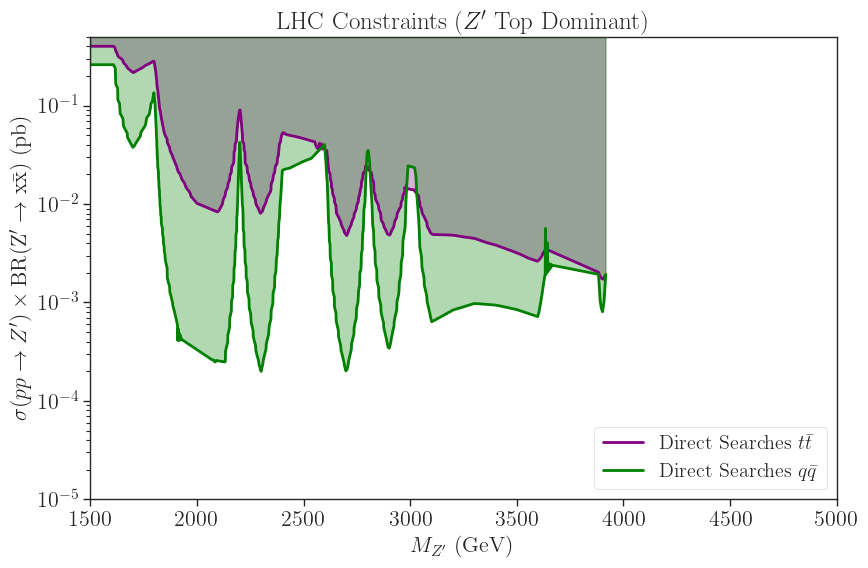

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
df_qq = pd.read_csv('./Exclusion_Contours_topDom_qq.csv')
df_tt = pd.read_csv('./Exclusion_Contours_topDom_tt.csv')

r_target = 1.0 / 1.5
upper_limit = 0.5  # This MUST match your plt.ylim() upper bound!

def plot_simple_fill(df, color, label):
    # Filter for target r-value and drop the NaNs used for segment breaks
    df_filtered = df[np.isclose(df['r_value'], r_target)].dropna()
    
    if df_filtered.empty:
        return
        
    # --- THE SIMPLE METHOD ---
    # 1. Round the mass to the nearest integer so we can group points together safely
    df_filtered['mZp_round'] = df_filtered['mZp_GeV'].round(0)
    
    # 2. For every mass point, find the absolute minimum cross-section.
    # This automatically flattens any loops or overhangs into a single clean line.
    line_data = df_filtered.groupby('mZp_round')['xsecXBR_pb'].min().reset_index()
    
    # 3. Sort strictly from left to right
    line_data = line_data.sort_values('mZp_round')
    
    x = line_data['mZp_round'].values
    y = line_data['xsecXBR_pb'].values
    
    # Extend to the y-axis if the data starts after 1500
    if len(x) > 0 and x[0] > 1500.0:
        x = np.insert(x, 0, 1500.0)
        y = np.insert(y, 0, y[0])
        
    # Plot the line linking the points
    plt.plot(x, y, color=color, linewidth=2, linestyle='solid', label=label)
    
    # Fill the region between the dots and the maximum value
    plt.fill_between(x, y, upper_limit, color=color, alpha=0.3)

# ---------------------------------------------------------
# Create the Final Plot
# ---------------------------------------------------------
fig = plt.figure(figsize=(9, 6))

plot_simple_fill(df_tt, color='purple', label=r'Direct Searches $t\bar{t}$')
plot_simple_fill(df_qq, color='green', label=r'Direct Searches $q\bar{q}$')

# Formatting
plt.legend(loc='lower right', fontsize=14.5, framealpha=0.5)
plt.yscale('log')
plt.xlabel(r'$M_{Z^\prime}$ (GeV)', fontsize=16)
plt.ylabel(r'$\sigma(pp \to Z^\prime) \times \rm{BR}(Z^\prime \to x\bar{x})$ (pb)', fontsize=16)

plt.xlim(1500, 5000)
plt.ylim(1e-5, upper_limit)

plt.title(r'LHC Constraints ($Z^\prime$ Top Dominant)', fontsize=18)
plt.tight_layout()
plt.savefig('allExclusions_v2_Corrected.png', dpi=300)
plt.show()